In [ ]:
uuid_alumno = "1ba86120-4b39-496b-bc7f-177f7748db97"

# 🎾 Asistente Experto en Reglamentos de Tenis
### RAG + Agente LangGraph con Google Gemini

**Proyecto Final — IA Generativa** · Máster en Data Science (Evolve)

Este notebook construye un **agente conversacional** que responde dudas sobre el
reglamento del **Ranking Federado del Distrito de Moncloa-Aravaca 2025-2026**
(un torneo de tenis amateur) usando **RAG**. Si la duda es sobre reglas generales
del juego que ese reglamento no cubre, el agente **recurre automáticamente** a las
**Reglas del Tenis de la ITF 2026** como fuente de respaldo.

| Componente | Tecnología |
|---|---|
| LLM y Embeddings | Google Gemini (`gemini-2.5-flash` + `text-embedding-004`) |
| Base vectorial | ChromaDB (2 colecciones, una por reglamento) |
| Framework de agente | LangGraph (`create_react_agent`) |
| Memoria | `InMemorySaver` + `thread_id` |

## 1. Configuración del entorno

Cargamos la API key de Gemini desde `.env` (nunca escrita en el código) y
añadimos la raíz del proyecto al `sys.path` para importar el paquete `src`,
que contiene la lógica reutilizable (misma base de código que la app de Streamlit).

In [1]:
# Si hace falta, instalá las dependencias (descomentá):
# %pip install -r ../requirements.txt

import sys, pathlib
ROOT = pathlib.Path.cwd().parent   # .../proyecto_IA_gen
sys.path.insert(0, str(ROOT))

from src.config import load_api_key
load_api_key()   # normaliza GEMINI_API_KEY -> GOOGLE_API_KEY
print('API key de Gemini cargada correctamente ✔')

API key de Gemini cargada correctamente ✔


## 2. Construcción de la base de conocimiento vectorial

Cargamos cada PDF, lo troceamos con `RecursiveCharacterTextSplitter`
(1000 caracteres, 150 de solape) y creamos **dos colecciones ChromaDB**
independientes con **Gemini Embeddings**. Mantenerlas separadas es lo que
permite el enrutamiento jerárquico del agente (torneo ▶ ITF).

> `obtener_vectorstores` **construye** las colecciones la primera vez (indexando
> por lotes para respetar el límite de ~100 embeddings/min del free tier de Gemini)
> y en ejecuciones posteriores las **carga de disco** (`./chroma_db`), sin volver a
> gastar cuota. Para forzar una reconstrucción, poné `RECONSTRUIR = True`.

In [2]:
from src.rag import obtener_vectorstores, construir_vectorstores

RECONSTRUIR = False   # poné True para reindexar desde cero
if RECONSTRUIR:
    vs_torneo, vs_itf = construir_vectorstores(persistir=True)
else:
    vs_torneo, vs_itf = obtener_vectorstores(persistir=True)

print('Colección TORNEO:', vs_torneo._collection.count(), 'fragmentos')
print('Colección ITF   :', vs_itf._collection.count(), 'fragmentos')

Colección TORNEO: 24 fragmentos
Colección ITF   : 133 fragmentos


### 2.1. Verificación de la base vectorial (antes de conectar el agente)

Como recomienda la consigna, comprobamos que cada colección responde a
consultas de prueba con una búsqueda por similitud directa.

In [3]:
from src.rag import formatear_documentos

print('--- TORNEO: "puntos del ranking" ---')
print(formatear_documentos(vs_torneo.similarity_search('cómo se reparten los puntos del ranking', k=2)))
print()
print('--- ITF: "tie-break" ---')
print(formatear_documentos(vs_itf.similarity_search('cómo funciona el tie-break', k=2)))

--- TORNEO: "puntos del ranking" ---


[Fragmento 1 · Reglamento Torneo Moncloa-Aravaca 2025-2026 · pág. 6]
consecutivos o no, se les dará la baja temporal del mismo. 
 
 
7. Otros aspectos de la competición  
 
7.1. El ranking tiene dos clasificaciones, la clasificación general, que se construye en base a los 
puestos disputados en cada reto, y la clasificación de la regularidad, que se construye en base al 
mayor número de partidos, sets y juegos ganados. Los 3 primeros de cada clasificación 
obtendrán un trofeo 
La clasificación general podrá alterarse por la entrada de nuevos participantes, aunque este 
hecho sólo podrá ocurrir en los retos por 1 puesto, único momento en el que se admiten nuevos 
participantes con puntuación. 
 
7.2. Las bajas de participantes producirán huecos en los retos siguientes (Bye) hasta llegar a 
una jornada cuyo reto sea por 1 puesto, momento en el que se reajustará el ranking. No obstante 
las bajas podrán ser cubiertas por nuevos jugadores que estén proceso de incorporación al

[Fragmento 2

[Fragmento 1 · Reglas del Tenis ITF 2026 · pág. 9]
6 
 
b. Juego de tie-break  
 
Durante el juego de tie -break, se cantan los puntos “cero”,  “1”, “2”, “3”, etc. 
El primer jugador o equipo que obtenga siete puntos gana el “juego” y el 
“set”, siempre que haya un margen de dos puntos por encima del contrario. Si 
es necesario, el juego de tie-break continuará hasta que se consiga ese margen.  
 
El jugador al que le toque sacar será el servidor del primer punto del juego de 
tie-break. Los dos puntos siguientes los servirá el contrario o contrarios (en 
dobles, el jugador del equipo contrario al que le toque servir después). 
Después de esto, cada jugador o equipo servirá alternativamente dos puntos 
consecutivos hasta el final del juego de tie -break (en dobles, la rotación del 
servicio dentro de cada equipo continuará en el mismo orden mantenido 
durante el set).  
 
El jugador o equipo al que le toque servir primero en el juego de tie-break será 
el restador en el primer juego de

## 3. System prompt y herramientas del agente

El agente dispone de **dos herramientas de recuperación** y un **system prompt**
que impone la jerarquía: primero el reglamento del torneo, y solo si no encuentra
la respuesta, el reglamento ITF. Las decisiones de diseño del prompt están
justificadas en el README. Lo mostramos aquí para dejarlo a la vista:

In [4]:
from src.agent import SYSTEM_PROMPT
print(SYSTEM_PROMPT)

Eres un asistente experto en la normativa del "Ranking Federado del Distrito de Moncloa-Aravaca 2025-2026", un torneo de tenis amateur.

Tu base de conocimiento tiene DOS reglamentos y DEBES respetar esta jerarquía:

1. FUENTE PRINCIPAL — el reglamento del torneo (herramienta `buscar_reglamento_torneo`).
   Úsala SIEMPRE primero para cualquier pregunta sobre inscripción, ranking, puntos,
   partidos, plazos, categorías, sanciones o funcionamiento del torneo.

2. FUENTE DE RESPALDO — las Reglas del Tenis de la ITF (herramienta `buscar_reglamento_itf`).
   Úsala SOLO cuando el reglamento del torneo NO cubra la duda: reglas generales del
   juego (puntuación de un partido, tie-break, saque, cambios de lado, etc.).

Cómo debes comportarte:
- Antes de responder algo técnico, consulta la(s) herramienta(s) correspondiente(s).
- Si la respuesta está en el reglamento del torneo, respóndela con esa fuente y NO
  consultes la ITF.
- Si el torneo no lo cubre, indícalo y consulta la ITF como norma 

## 4. Construcción del agente en LangGraph

`create_react_agent` arma el grafo ReAct: recibe la pregunta, decide qué
herramienta usar, recupera contexto de ChromaDB y genera la respuesta con Gemini.
El `checkpointer` (`InMemorySaver`) le da **memoria** por `thread_id`.

In [5]:
from src.agent import construir_agente, preguntar

# Reutiliza las colecciones ya persistidas en el paso 2.
agente = construir_agente(persistir_chroma=True)
print('Agente listo ✔')

Agente listo ✔


### 4.1. Visualización del grafo

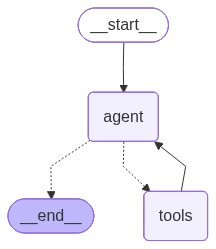

In [6]:
from IPython.display import Image, display
try:
    display(Image(agente.get_graph().draw_mermaid_png()))
except Exception as e:
    print('(No se pudo renderizar el diagrama:', e, ')')
    print(agente.get_graph().draw_ascii())

## 5. Demostración de la memoria de conversación

Hacemos una pregunta y luego una **segunda pregunta que hace referencia a la
anterior** ("¿y quién paga la pista en *ese caso*?") sin repetir el contexto. El
agente entiende que "ese caso" es el W.O. de la pregunta anterior gracias a la
memoria del `thread_id`.

In [7]:
tid = 'demo-memoria'
p1 = '¿qué es un W.O. y cuánto tiempo de cortesía hay antes de aplicarlo?'
p2 = '¿y quién paga la reserva de la pista en ese caso?'   # 'ese caso' referencia a P1
print('P1:', p1)
print('R1:', preguntar(agente, p1, thread_id=tid))
print()
print('P2 (referencia a la anterior):', p2)
print('R2:', preguntar(agente, p2, thread_id=tid))

P1: ¿qué es un W.O. y cuánto tiempo de cortesía hay antes de aplicarlo?


R1: Un W.O. (Walk Over) se produce cuando un jugador no se presenta a un partido y se le da la victoria a su oponente. Según el reglamento del torneo, hay 20 minutos de espera o de cortesía antes de aplicar un W.O. Esto significa que si un jugador no se presenta dentro de los 20 minutos después del horario programado para el partido, se le considerará un W.O. y se le dará la victoria a su oponente.

Fuente: Reglamento Torneo Moncloa-Aravaca 2025-2026, página 2, artículo 1.6.

P2 (referencia a la anterior): ¿y quién paga la reserva de la pista en ese caso?


R2: Según el reglamento del torneo, si un jugador no se presenta a un partido y se produce un W.O., el jugador que no ha comparecido deberá abonar el importe total de la reserva de la pista al jugador que la reservó, salvo que el jugador que reservó la pista pueda utilizarla de otro modo.

Fuente: Reglamento Torneo Moncloa-Aravaca 2025-2026, página 2, artículo 1.7.


## 6. Cinco preguntas de ejemplo documentadas

Cinco consultas que ejercitan la jerarquía: unas se responden con el reglamento
del torneo y otras caen al reglamento ITF.

In [8]:
preguntas_demo = [
    'cómo se reparten los puntos del ranking del torneo?',      # -> TORNEO
    'qué pasa si un jugador no se presenta a su partido?',       # -> TORNEO
    'cuál es el plazo para disputar cada ronda?',                # -> TORNEO
    'cómo funciona un tie-break?',                               # -> ITF (respaldo)
    'cuántos sets se juegan y cómo se gana un set?',             # -> ITF (respaldo)
]

for i, q in enumerate(preguntas_demo, 1):
    print(f'{"="*80}\n[{i}] {q}\n{"-"*80}')
    print(preguntar(agente, q, thread_id=f'demo-{i}'))
    print()

[1] cómo se reparten los puntos del ranking del torneo?
--------------------------------------------------------------------------------


El reglamento del torneo Moncloa-Aravaca 2025-2026 establece que el ranking tiene dos clasificaciones: la clasificación general y la clasificación de la regularidad. La clasificación general se construye en base a los puestos disputados en cada reto, y la clasificación de la regularidad se construye en base al mayor número de partidos, sets y juegos ganados.

La tabla de puestos de entrada en el ranking con partido de nivel es la siguiente:

* Victoria/Derrota en 3 sets: Puesto 35
* Victoria/Derrota en 2 sets con 2/3 juegos de diferencia: Puesto 35
* Victoria en 2 sets con 4 a 6 juegos de diferencia: Puesto 27
* Derrota en 2 sets con 4 a 6 juegos de diferencia: Puesto 42
* Victoria en 2 sets con 7 a 9 juegos de diferencia: Puesto 21
* Derrota en 2 sets con 7 a 9 juegos de diferencia: Puesto 52
* Victoria en 2 sets con 10 a 12 juegos de diferencia: Puesto 15

Además, el reglamento establece que los jugadores que no contacten con su rival en el plazo previsto y no se dispute el partido, 

Según el reglamento del torneo, si un jugador no se presenta a su partido, se le dará el partido por perdido por W.O. (walkover) después de 20 minutos de espera. Además, el jugador que no se presentó deberá abonar el importe total de la reserva de la pista al jugador que la reservó, salvo que el jugador que reservó la pista pueda utilizarla de otro modo.

En cuanto a las penalizaciones, si un jugador no contacta con su rival en el plazo previsto y no se disputa el partido, bajará 6 posiciones en la tabla. Si esto sucede una segunda vez, bajará 12 posiciones, y si se produce una tercera vez y las siguientes, se producirá la baja temporal del mismo.

Es importante destacar que el reglamento del torneo establece que los jugadores deben intentar jugar los partidos del mismo y que las penalizaciones están diseñadas para fomentar la disputa de los partidos.

[3] cuál es el plazo para disputar cada ronda?
--------------------------------------------------------------------------------


El plazo para disputar cada ronda es de 14 días, salvo que por inclemencias meteorológicas, existencia de festividades/puentes o de otra índole se prorrogue la jornada una o dos semanas más. Esto se establece en el reglamento del torneo en el punto 1.3 (pág. 1).

[4] cómo funciona un tie-break?
--------------------------------------------------------------------------------


El reglamento del torneo "Ranking Federado del Distrito de Moncloa-Aravaca 2025-2026" establece que los partidos se jugarán al mejor de tres sets con tie-break en los tres. Los jugadores podrán pactar que el tercer set se juegue con un tie-break o un super tie-break. 

Sin embargo, el reglamento del torneo no proporciona detalles específicos sobre cómo funciona un tie-break. Por lo tanto, se consultó la normativa general de la ITF, que establece que un tie-break es un juego especial que se juega cuando el puntaje en un set es de 6-6. El primer jugador o equipo que gane siete puntos gana el tie-break y el set, siempre que haya un margen de dos puntos por encima del contrario. Si es necesario, el juego de tie-break continuará hasta que se consiga ese margen.

En resumen, un tie-break es un juego especial que se juega en un set cuando el puntaje es de 6-6, y el primer jugador o equipo que gane siete puntos gana el tie-break y el set, siempre que haya un margen de dos puntos por encima del

Según el reglamento del torneo "Ranking Federado del Distrito de Moncloa-Aravaca 2025-2026", cada partido se juega al mejor de tres sets con tie-break en los tres. Un set se gana cuando un jugador o equipo gana seis juegos, siempre que tenga una ventaja de dos juegos sobre su oponente. Si el marcador alcanza seis juegos iguales para ambos, se juega un tie-break. En el tie-break, el primer jugador o equipo que gane siete puntos gana el juego y el set, siempre que tenga una ventaja de dos puntos sobre su oponente.

Fuente: Reglamento Torneo Moncloa-Aravaca 2025-2026, pág. 1 y 3. 

Además, según las Reglas del Tenis de la ITF 2026, un set se puede ganar de dos maneras: mediante el "set de ventaja" o el "set de tie-break". En el "set de ventaja", el primer jugador o equipo que gane seis juegos gana el set, siempre que tenga una ventaja de dos juegos sobre su oponente. En el "set de tie-break", el primer jugador o equipo que gane siete puntos gana el juego y el set, siempre que tenga una ve

## 7. Celda interactiva de chat

Ejecutá esta celda y escribí tus preguntas. Escribí `salir` para terminar.
Comparte un mismo `thread_id`, así que la conversación tiene memoria.

In [ ]:
tid_chat = 'chat-interactivo'
print('🎾 Asistente del reglamento (escribí "salir" para terminar)\n')
while True:
    try:
        pregunta = input('Vos > ').strip()
    except (EOFError, KeyboardInterrupt):
        break
    if pregunta.lower() in {'salir', 'exit', 'quit', ''}:
        print('¡Hasta luego!')
        break
    print('Asistente >', preguntar(agente, pregunta, thread_id=tid_chat), '\n')